In [2]:
!nvidia-smi

Thu Jun 25 15:30:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)

OS                     Linux-6.6.122+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.13
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   47.4/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
torch                  ✅ 2.11.0+cu128>=1.8.0
torch                  ✅ 2.11.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision            ✅ 0.26.0+cu128

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="zx3ilJ1MB6oUz9xP9KWS")
project = rf.workspace("ekanshs-workspace-j7ydu").project("swords-2-lqorv")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Swords-2-1 in yolov8:: 100%|██████████| 3634/3634 [00:00<00:00, 6904.16it/s]


In [5]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,      # can use full 640 now since T4 GPU handles it
    batch=16,
    lr0=0.01,
    patience=25,
    project="swords_detection",
    name="run1",

)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Swords-2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0e432351c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
from ultralytics import YOLO

model = YOLO("runs/detect/swords_detection/run1/weights/best.pt")

# Lowering iou from the default 0.6 to 0.45 suppresses overlapping duplicates
metrics = model.val(iou=0.50, conf=0.25)
print(f"mAP@50: {metrics.box.map50:.2%}")
print(f"mAP@50-95: {metrics.box.map:.2%}")
print(f"Precision: {metrics.box.mp:.2%}")
print(f"Recall: {metrics.box.mr:.2%}")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1599.7±619.5 MB/s, size: 38.4 KB)
val: Scanning /content/Swords-2-1/valid/labels.cache... 211 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 211/211 63.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.0it/s 7.0s
                   all        211        386      0.586      0.521      0.398      0.165
Speed: 2.5ms preprocess, 24.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50: 39.84%
mAP@50-95: 16.49%
Precision: 58.60%
Recall: 52.07%



image 1/1 /content/Swords-2-1/train/images/015bb53494b2999770eb3b2dc0a53a1f_jpg.rf.03a5b2c4301dc455a1009ede928f4fe2.jpg: 640x640 1 swords, 36.8ms
Speed: 2.1ms preprocess, 36.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Class: swords
Confidence: 60.17%
Bounding box: tensor([[157.6464,  56.8282, 454.8926, 625.7620]], device='cuda:0')


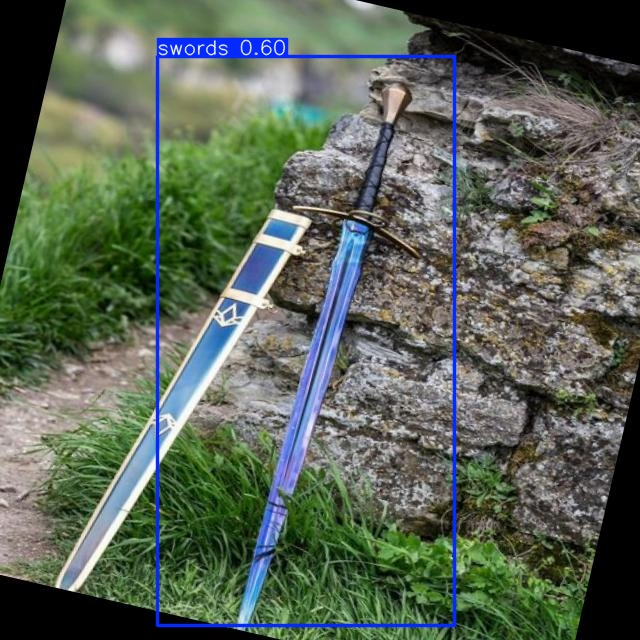

In [15]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
model = YOLO("runs/detect/swords_detection/run1/weights/best.pt")
results = model.predict("/content/Swords-2-1/train/images/015bb53494b2999770eb3b2dc0a53a1f_jpg.rf.03a5b2c4301dc455a1009ede928f4fe2.jpg", conf=0.35, iou=0.40, save=True)
for result in results:
    boxes = result.boxes
    for box in boxes:
        print(f"Class: {result.names[int(box.cls)]}")
        print(f"Confidence: {box.conf.item():.2%}")
        print(f"Bounding box: {box.xyxy}")

# Save image with boxes drawn on it
results[0].save(filename="prediction_output.jpg")
IPImage("prediction_output.jpg")